# Ablation, calibration and leakage Notebook

**Purpose.** Analyses 1 and 2 of the report: the three-arm ablation with paired, resampling-corrected tests; calibration and nested recalibration; and the nearest-neighbour leakage sensitivity analysis.

**Inputs:** `results/features_wgs.csv` from notebook 01.
**Outputs:** `results/ablation.pkl`, `results/leakage.csv`, the Table 4.1–4.4 CSV files, and Figures 4.2–4.4.

In [2]:
# ---- Setup: imports, run mode and folders --------------------------------------------
import os, time, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.exceptions import ConvergenceWarning

import common, engine
from common import load, feature_matrix, sha256, logit, expit, LENGTHS, EXPECTED_SHA256
from engine import splits, fit_predict, pooled_metrics, nb_corrected_t

# Elastic-net fits at the weakest penalties on the path can stop before full convergence;
# this is expected and does not affect the selected model, so these warnings are hidden.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
# openpyxl warns about an Excel extension it cannot read; it does not affect the data.
warnings.filterwarnings("ignore", message="Unknown extension is not supported")

# Output folders: tables and cached results in results/, figures in figures/
RES = Path("results")
FIG = Path("figures")
RES.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
DATA = Path("data/elife-71569-supp1-v2.xlsx")

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
print("Repeats:", engine.N_REPEATS, "| random-forest trees:", engine.RF_TREES)

C:\Users\5320\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Repeats: 20 | random-forest trees: 500


In [3]:
# Load the features produced by notebook 01 and assemble the arms (Table 3.3)
F = pd.read_csv(RES / "features_wgs.csv")
F = F[F.vaf_ctdna.notna()].reset_index(drop=True)
y = F.vaf_ctdna.to_numpy()
frag_cols = [col for col in F.columns if col not in ("ichorCNA", "vaf_ctdna")]
XA = F[frag_cols].to_numpy()                  # Arm A: 14 fragmentomic features
XB = logit(F[["ichorCNA"]].to_numpy())        # Arm B: ichorCNA, on the same logit scale as the outcome
XC = np.column_stack([XA, XB])                # Arm C: both
arms = {"A_frag14": XA, "A1_shortlong": F[["short_long_ratio"]].to_numpy(), "B_ichor": XB, "C_combined": XC}
S = splits(len(y))                            # the SAME 100 splits for every arm -> paired comparisons
n_tr, n_te = len(y) * 4 / 5, len(y) / 5       # about 68.8 training and 17.2 test samples per split
print(len(y), "samples |", len(S), "train/test splits")

86 samples | 100 train/test splits


## 1. Run the ablation (Analysis 1) with nested recalibration (Analysis 2)

For every split, each arm is fitted on the training fold and predicts the test fold. The recalibrated predictions come from a linear map learned only from inner cross-validated predictions on the training fold (`fit_predict` in `engine.py`), so they are as free of leakage as the raw ones.

In [4]:
cache = RES / "ablation.pkl"
if cache.exists():
    out = pickle.load(open(cache, "rb"))
    print("Loaded cached results from", cache)
else:
    out, t0 = {}, time.time()
    for model in ["EN", "RF"]:
        for arm, X in arms.items():
            raw = np.full((engine.N_REPEATS, len(y)), np.nan); rec = raw.copy(); fr, frr = [], []
            for s, (tr, te) in enumerate(S):
                r = s // engine.N_SPLITS                   # which repeat this split belongs to
                (p,), (q,) = fit_predict(model, X[tr], y[tr], [X[te]], recal=True, seed=s)
                raw[r, te], rec[r, te] = p, q
                fr.append(np.sqrt(np.mean((y[te] - p) ** 2)))
                frr.append(np.sqrt(np.mean((y[te] - q) ** 2)))
            out[(arm, model)] = dict(raw=raw, rec=rec, fold_rmse=np.array(fr), fold_rmse_rec=np.array(frr))
            print(f"{model} {arm}: done ({time.time() - t0:.0f} s)")
    # Null model: always predicts the training-fold mean (computed on the logit scale)
    raw, fr = np.full((engine.N_REPEATS, len(y)), np.nan), []
    for s, (tr, te) in enumerate(S):
        p = np.full(len(te), expit(logit(y[tr]).mean()))
        raw[s // engine.N_SPLITS, te] = p
        fr.append(np.sqrt(np.mean((y[te] - p) ** 2)))
    out[("Null", "-")] = dict(raw=raw, rec=raw, fold_rmse=np.array(fr), fold_rmse_rec=np.array(fr))
    pickle.dump(out, open(cache, "wb"))

Loaded cached results from results\ablation.pkl


## 2. Performance of each arm (Table 4.1)

Metrics are computed on the 86 pooled out-of-fold predictions of each repeat, then summarised across repeats. The 2.5th–97.5th percentiles show how much results move with the partition; they are **not** confidence intervals.

In [5]:
def summarise(key):
    rows = []
    for (arm, model), v in out.items():
        ms = pd.DataFrame([pooled_metrics(y, v[key][r]) for r in range(engine.N_REPEATS)])
        row = dict(arm=arm, model=model, **ms.median().to_dict())
        row["rmse_p2.5"], row["rmse_p97.5"] = ms.rmse.quantile(.025), ms.rmse.quantile(.975)
        rows.append(row)
    return pd.DataFrame(rows)

raw_tab = summarise("raw")
direct = dict(arm="ichorCNA used directly", model="-", **pooled_metrics(y, F.ichorCNA.to_numpy()))
raw_tab = pd.concat([raw_tab, pd.DataFrame([direct])], ignore_index=True)
raw_tab.to_csv(RES / "table_4_1_performance.csv", index=False)
display(raw_tab[["arm", "model", "rmse", "rmse_p2.5", "rmse_p97.5", "mae", "r2", "spearman"]].round(3))

,arm,model,rmse,rmse_p2.5,rmse_p97.5,mae,r2,spearman
0,A_frag14,EN,0.172,0.164,0.188,0.118,0.571,0.731
1,A1_shortlong,EN,0.204,0.200,0.209,0.148,0.399,0.614
2,B_ichor,EN,0.163,0.160,0.168,0.114,0.617,0.823
3,C_combined,EN,0.157,0.150,0.174,0.107,0.641,0.823
4,A_frag14,RF,0.178,0.168,0.193,0.121,0.541,0.749
5,A1_shortlong,RF,0.211,0.203,0.228,0.160,0.354,0.573
6,B_ichor,RF,0.175,0.163,0.185,0.122,0.558,0.777
7,C_combined,RF,0.158,0.149,0.175,0.105,0.639,0.820
8,Null,-,0.274,0.272,0.278,0.220,-0.088,-0.170
9,ichorCNA used directly,-,0.176,NaN,NaN,0.118,0.548,0.829


## 3. Paired comparisons with the corrected test (Table 4.2)

Per-fold differences in RMSE are correlated because training sets overlap, so their variance is inflated following Nadeau and Bengio (2003) before the confidence interval and p-value are computed. Negative differences favour the first arm.

In [6]:
contrasts = [("C_combined", "B_ichor"), ("A_frag14", "B_ichor"), ("C_combined", "A_frag14"),
             ("A_frag14", "A1_shortlong"), ("B_ichor", "Null")]
rows = []
for model in ["EN", "RF"]:
    for a, b in contrasts:
        kb = ("Null", "-") if b == "Null" else (b, model)
        for key in ["fold_rmse", "fold_rmse_rec"]:
            if b == "Null" and key == "fold_rmse_rec":
                continue
            r = nb_corrected_t(out[(a, model)][key] - out[kb][key], n_tr, n_te)
            rows.append(dict(model=model, contrast=f"{a} - {b}",
                             predictions="recalibrated" if key.endswith("rec") else "raw", **r))
tests = pd.DataFrame(rows)
tests.to_csv(RES / "table_4_2_tests.csv", index=False)
display(tests[tests.predictions == "raw"].round(4))

# The trap described in Section 4.2: consistency across repeats is not evidence of a real gain
for model in ["EN", "RF"]:
    wins = sum(pooled_metrics(y, out[("C_combined", model)]["raw"][r])["rmse"]
               < pooled_metrics(y, out[("B_ichor", model)]["raw"][r])["rmse"] for r in range(engine.N_REPEATS))
    print(f"{model}: Arm C beat Arm B in {wins} of {engine.N_REPEATS} repeats - compare with the corrected test above.")

,model,contrast,predictions,mean,lo,hi,t,p
0,EN,C_combined - B_ichor,raw,-0.0059,-0.0251,0.0133,-0.6086,0.5442
2,EN,A_frag14 - B_ichor,raw,0.0089,-0.0193,0.0371,0.6268,0.5323
4,EN,C_combined - A_frag14,raw,-0.0148,-0.0345,0.0049,-1.4932,0.1386
6,EN,A_frag14 - A1_shortlong,raw,-0.0300,-0.0640,0.0041,-1.7478,0.0836
8,EN,B_ichor - Null,raw,-0.1111,-0.1538,-0.0685,-5.1759,0.0000
9,RF,C_combined - B_ichor,raw,-0.0162,-0.0471,0.0147,-1.0386,0.3015
11,RF,A_frag14 - B_ichor,raw,0.0049,-0.0286,0.0383,0.2876,0.7742
13,RF,C_combined - A_frag14,raw,-0.0210,-0.0345,-0.0076,-3.1146,0.0024
15,RF,A_frag14 - A1_shortlong,raw,-0.0343,-0.0726,0.0040,-1.7772,0.0786
17,RF,B_ichor - Null,raw,-0.1006,-0.1470,-0.0542,-4.3004,0.0000


EN: Arm C beat Arm B in 18 of 20 repeats - compare with the corrected test above.
RF: Arm C beat Arm B in 18 of 20 repeats - compare with the corrected test above.


## 4. Calibration before and after nested recalibration (Table 4.4)

A slope of 1 and a mean bias (calibration-in-the-large) of 0 indicate good calibration; a positive mean bias means the predictions are too low on average.

In [7]:
rec_tab = summarise("rec")
cal = raw_tab[["arm", "model", "cal_slope", "citl", "rmse", "mae"]].merge(
    rec_tab[["arm", "model", "cal_slope", "citl", "rmse", "mae"]], on=["arm", "model"], how="left",
    suffixes=("_raw", "_recalibrated"))
cal.to_csv(RES / "table_4_4_calibration.csv", index=False)
display(cal.round(3))
print("C - B after recalibration:")
display(tests[(tests.predictions == "recalibrated") & (tests.contrast == "C_combined - B_ichor")].round(4))

,arm,model,cal_slope_raw,citl_raw,rmse_raw,mae_raw,cal_slope_recalibrated,citl_recalibrated,rmse_recalibrated,mae_recalibrated
0,A_frag14,EN,0.928,0.029,0.172,0.118,1.002,-0.001,0.170,0.126
1,A1_shortlong,EN,0.923,0.045,0.204,0.148,1.004,0.001,0.199,0.159
2,B_ichor,EN,0.947,0.017,0.163,0.114,0.999,-0.000,0.162,0.118
3,C_combined,EN,0.966,0.025,0.157,0.107,1.018,0.001,0.157,0.112
4,A_frag14,RF,1.035,0.037,0.178,0.121,0.986,0.001,0.175,0.126
5,A1_shortlong,RF,0.762,0.025,0.211,0.160,0.972,-0.000,0.207,0.165
6,B_ichor,RF,0.877,0.008,0.175,0.122,1.014,-0.002,0.172,0.126
7,C_combined,RF,1.055,0.027,0.158,0.105,0.988,-0.002,0.153,0.104
8,Null,-,-3.622,0.067,0.274,0.220,-3.622,0.067,0.274,0.220
9,ichorCNA used directly,-,1.087,0.071,0.176,0.118,NaN,NaN,NaN,NaN


C - B after recalibration:


,model,contrast,predictions,mean,lo,hi,t,p
1,EN,C_combined - B_ichor,recalibrated,-0.0063,-0.0247,0.0121,-0.6787,0.4989
10,RF,C_combined - B_ichor,recalibrated,-0.0173,-0.0495,0.0150,-1.0631,0.2903


## 5. Leakage sensitivity analysis (Table 4.3)

Repeat samples from the same patient cannot be kept together without identifiers. Instead, each test sample's *k* nearest neighbours (in the standardised predictor space, computed from features only) are removed from the training fold, and the result is compared with removing the same number of training samples at random. A gain that relies on near-duplicate samples should shrink under neighbour removal but not under random removal.

In [8]:
from sklearn.preprocessing import StandardScaler
cache = RES / "leakage.csv"
if cache.exists():
    Lk = pd.read_csv(cache)
    print("Loaded cached results from", cache)
else:
    Z = StandardScaler().fit_transform(XC)                 # features only: no outcome values are used
    Dm = ((Z[:, None] - Z[None]) ** 2).sum(-1)
    rows = []
    for k in [1, 2]:
        rng = np.random.default_rng(7)                     # re-seeded for each k, as in the report's run
        for s, (tr, te) in enumerate(S):
            nn = set()
            for i in te:
                order = tr[np.argsort(Dm[i, tr])]
                nn.update(order[:k].tolist())
            nn = np.array(sorted(nn)); n_rm = len(nn)
            conds = {"nn_excluded": np.setdiff1d(tr, nn),
                     "random_excluded": np.setdiff1d(tr, rng.choice(tr, n_rm, replace=False))}
            for cond, trr in conds.items():
                for model in ["EN", "RF"]:
                    r = {}
                    for arm, X in [("A", XA), ("B", XB), ("C", XC)]:
                        (p,), _ = fit_predict(model, X[trr], y[trr], [X[te]], seed=s)
                        r[arm] = np.sqrt(np.mean((y[te] - p) ** 2))
                    rows.append(dict(k=k, split=s, cond=cond, model=model, n_train=len(trr), **r))
        print("k =", k, "done")
    Lk = pd.DataFrame(rows); Lk.to_csv(cache, index=False)

rows = []
for model in ["EN", "RF"]:
    full = {a: out[(n, model)]["fold_rmse"] for a, n in [("A", "A_frag14"), ("B", "B_ichor"), ("C", "C_combined")]}
    r = nb_corrected_t(full["C"] - full["B"], n_tr, n_te)
    rows.append(dict(model=model, training_set="full training folds", rmse_A=full["A"].mean(),
                     rmse_B=full["B"].mean(), rmse_C=full["C"].mean(), C_minus_B=r["mean"], p=r["p"]))
    for k in [1, 2]:
        for cond in ["random_excluded", "nn_excluded"]:
            sub = Lk[(Lk.model == model) & (Lk.k == k) & (Lk.cond == cond)]
            r = nb_corrected_t(sub.C - sub.B, sub.n_train.mean(), n_te)
            rows.append(dict(model=model, training_set=f"k={k}, {cond}", rmse_A=sub.A.mean(),
                             rmse_B=sub.B.mean(), rmse_C=sub.C.mean(), C_minus_B=r["mean"], p=r["p"]))
leak = pd.DataFrame(rows)
leak.to_csv(RES / "table_4_3_leakage.csv", index=False)
display(leak.round(4))

Loaded cached results from results\leakage.csv


,model,training_set,rmse_A,rmse_B,rmse_C,C_minus_B,p
0,EN,full training folds,0.1685,0.1596,0.1537,-0.0059,0.5442
1,EN,"k=1, random_excluded",0.1726,0.1600,0.1573,-0.0028,0.8506
2,EN,"k=1, nn_excluded",0.1779,0.1605,0.1589,-0.0016,0.8981
3,EN,"k=2, random_excluded",0.1739,0.1608,0.1561,-0.0048,0.7476
4,EN,"k=2, nn_excluded",0.1874,0.1617,0.1649,0.0032,0.8578
5,RF,full training folds,0.1751,0.1702,0.1540,-0.0162,0.3015
6,RF,"k=1, random_excluded",0.1849,0.1727,0.1598,-0.0128,0.4542
7,RF,"k=1, nn_excluded",0.1906,0.1726,0.1642,-0.0084,0.6665
8,RF,"k=2, random_excluded",0.1891,0.1742,0.1645,-0.0096,0.6788
9,RF,"k=2, nn_excluded",0.2099,0.1721,0.1798,0.0077,0.7491


## 6. Figures 4.2–4.4

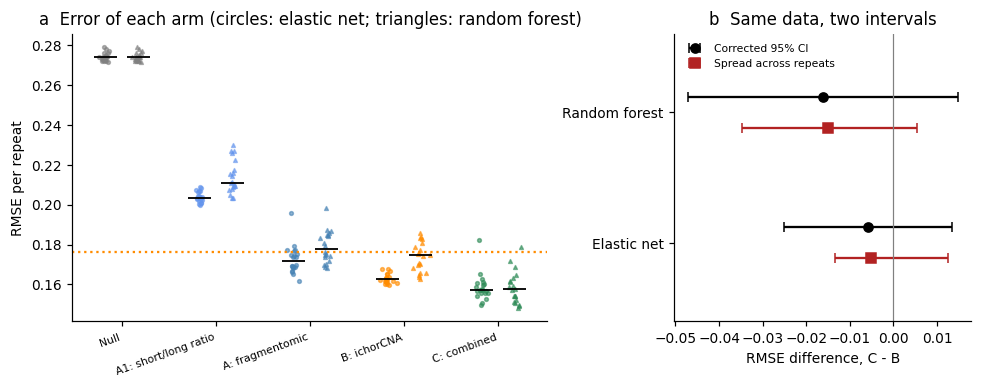

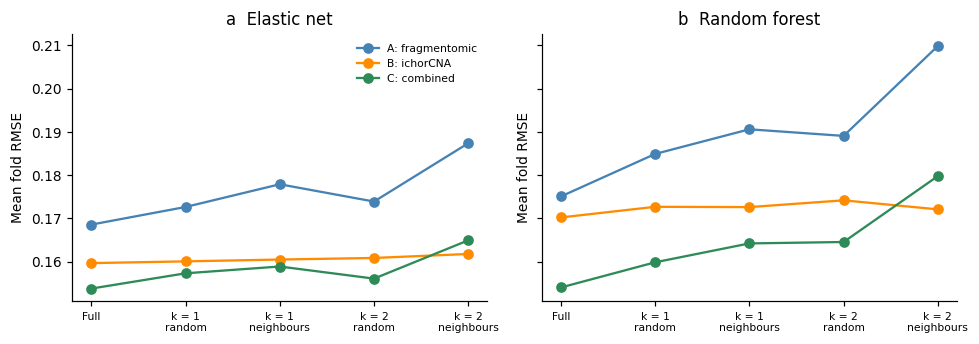

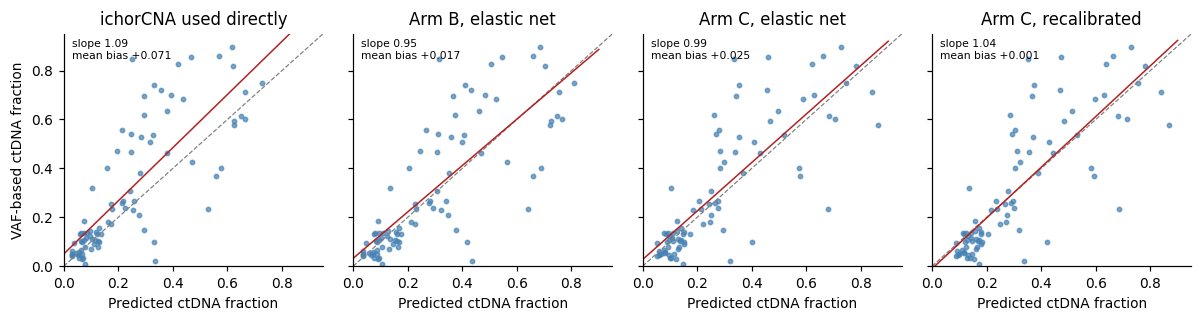

In [9]:
COL = {"A_frag14": "steelblue", "A1_shortlong": "cornflowerblue", "B_ichor": "darkorange", "C_combined": "seagreen", "Null": "grey"}
LAB = {"A_frag14": "A: fragmentomic", "A1_shortlong": "A1: short/long ratio", "B_ichor": "B: ichorCNA",
       "C_combined": "C: combined", "Null": "Null"}
order = ["Null", "A1_shortlong", "A_frag14", "B_ichor", "C_combined"]

# Figure 4.2: per-repeat RMSE, and the corrected interval next to the partition spread
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
for j, model in enumerate(["EN", "RF"]):
    for i, a in enumerate(order):
        key = ("Null", "-") if a == "Null" else (a, model)
        v = [pooled_metrics(y, out[key]["raw"][r])["rmse"] for r in range(engine.N_REPEATS)]
        x = i + (j - .5) * .35
        ax[0].scatter(np.full(len(v), x) + np.random.default_rng(i).normal(0, .03, len(v)), v, s=6,
                      c=COL[a], alpha=.6, marker="o" if model == "EN" else "^")
        ax[0].hlines(np.median(v), x - .12, x + .12, color="k", lw=1.2)
direct_rmse = pooled_metrics(y, F.ichorCNA.to_numpy())["rmse"]
ax[0].axhline(direct_rmse, ls=":", c="darkorange")
ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels([LAB[a] for a in order], rotation=20, ha="right", fontsize=7)
ax[0].set(ylabel="RMSE per repeat", title="a  Error of each arm (circles: elastic net; triangles: random forest)")
for j, model in enumerate(["EN", "RF"]):
    r = nb_corrected_t(out[("C_combined", model)]["fold_rmse"] - out[("B_ichor", model)]["fold_rmse"], n_tr, n_te)
    rep = [pooled_metrics(y, out[("C_combined", model)]["raw"][k])["rmse"]
           - pooled_metrics(y, out[("B_ichor", model)]["raw"][k])["rmse"] for k in range(engine.N_REPEATS)]
    ax[1].errorbar(r["mean"], j + .12, xerr=[[r["mean"] - r["lo"]], [r["hi"] - r["mean"]]], fmt="o", c="k",
                   capsize=3, label="Corrected 95% CI" if j == 0 else None)
    ax[1].errorbar(np.median(rep), j - .12, xerr=[[np.median(rep) - np.percentile(rep, 2.5)],
                   [np.percentile(rep, 97.5) - np.median(rep)]], fmt="s", c="firebrick", capsize=3,
                   label="Spread across repeats" if j == 0 else None)
ax[1].axvline(0, c="grey", lw=.8); ax[1].set_yticks([0, 1]); ax[1].set_yticklabels(["Elastic net", "Random forest"])
ax[1].set_ylim(-.6, 1.6); ax[1].set(xlabel="RMSE difference, C - B", title="b  Same data, two intervals")
ax[1].legend(frameon=False, fontsize=7, loc="upper left")
fig.tight_layout(); fig.savefig(FIG / "fig4_2_ablation.png", dpi=150); plt.show()

# Figure 4.3: leakage sensitivity
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for a_, model, name in zip(ax, ["EN", "RF"], ["a  Elastic net", "b  Random forest"]):
    s_ = leak[leak.model == model].reset_index(drop=True)
    labels = ["Full"] + [t.replace("k=", "k = ").replace(", nn_excluded", "\nneighbours").replace(", random_excluded", "\nrandom")
                         for t in s_.training_set[1:]]
    for arm, col, lab in [("A", "steelblue", "A: fragmentomic"), ("B", "darkorange", "B: ichorCNA"), ("C", "seagreen", "C: combined")]:
        a_.plot(range(len(s_)), s_[f"rmse_{arm}"], marker="o", c=col, label=lab)
    a_.set_xticks(range(len(s_))); a_.set_xticklabels(labels, fontsize=7)
    a_.set(title=name, ylabel="Mean fold RMSE")
ax[0].legend(frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "fig4_3_leakage.png", dpi=150); plt.show()

# Figure 4.4: calibration (each sample's predictions averaged over the repeats)
panels = [("ichorCNA used directly", F.ichorCNA.to_numpy()),
          ("Arm B, elastic net", out[("B_ichor", "EN")]["raw"].mean(0)),
          ("Arm C, elastic net", out[("C_combined", "EN")]["raw"].mean(0)),
          ("Arm C, recalibrated", out[("C_combined", "EN")]["rec"].mean(0))]
fig, ax = plt.subplots(1, 4, figsize=(11, 3), sharey=True)
for a_, (title, p) in zip(ax, panels):
    pm = pooled_metrics(y, p)
    a_.scatter(p, y, s=8, c="steelblue", alpha=.7); a_.plot([0, 1], [0, 1], c="grey", lw=.8, ls="--")
    xs = np.linspace(0, .9, 10); a_.plot(xs, pm["cal_intercept"] + pm["cal_slope"] * xs, c="firebrick", lw=1)
    a_.set(xlim=(0, .95), ylim=(0, .95), title=title, xlabel="Predicted ctDNA fraction")
    a_.text(.03, .85, f"slope {pm['cal_slope']:.2f}\nmean bias {pm['citl']:+.3f}", fontsize=7)
ax[0].set_ylabel("VAF-based ctDNA fraction")
fig.tight_layout(); fig.savefig(FIG / "fig4_4_calibration.png", dpi=150); plt.show()

## Comparison of model families 

Further analysis within each arm, the random forest is compared with the elastic net using the same corrected test on the per-fold RMSE differences. Positive differences favour the elastic net.

In [10]:
rows = []
for arm in ["A1_shortlong", "A_frag14", "B_ichor", "C_combined"]:
    d = out[(arm, "RF")]["fold_rmse"] - out[(arm, "EN")]["fold_rmse"]      # RF minus EN, per fold
    r = nb_corrected_t(d, n_tr, n_te)
    rep = [(pooled_metrics(y, out[(arm, "EN")]["raw"][k])["rmse"], pooled_metrics(y, out[(arm, "RF")]["raw"][k])["rmse"])
           for k in range(engine.N_REPEATS)]
    rows.append(dict(arm=arm, rmse_EN=np.median([e for e, _ in rep]), rmse_RF=np.median([f for _, f in rep]),
                     RF_minus_EN=r["mean"], lo=r["lo"], hi=r["hi"], p=r["p"],
                     repeats_favouring_EN=sum(e < f for e, f in rep)))
family = pd.DataFrame(rows)
family.to_csv(RES / "table_4_2_family_tests.csv", index=False)
display(family.round(4))

,arm,rmse_EN,rmse_RF,RF_minus_EN,lo,hi,p,repeats_favouring_EN
0,A1_shortlong,0.2035,0.2110,0.0108,-0.0159,0.0376,0.4225,19
1,A_frag14,0.1718,0.1778,0.0065,-0.0197,0.0327,0.6234,16
2,B_ichor,0.1625,0.1746,0.0106,-0.0073,0.0284,0.2426,20
3,C_combined,0.1573,0.1576,0.0003,-0.0249,0.0254,0.9839,10
